<a href="https://colab.research.google.com/github/artreas/DATA_SCEINCE_ASSIGNMENT/blob/main/Global_Terrorism_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Name - Global Terrorism Data Analysis**

Project Type - EDA

Contribution - Individual

Aniket Singh

**PROJECT SUMMARY**
This project focuses on analyzing the Global Terrorism Database (GTD), which contains detailed information on terrorist incidents worldwide from 1970 to 2017. The objective of this project is to perform Exploratory Data Analysis (EDA) to uncover meaningful patterns, trends, and insights related to global terrorism activities.

The dataset consists of over 180,000 records and includes attributes such as date, country, region, attack type, weapon type, number of casualties, and more. Due to the large size and complexity of the dataset, preprocessing steps such as handling missing values, selecting relevant features, and renaming columns were performed to make the data more suitable for analysis.

The analysis begins with understanding the structure of the dataset, including the number of rows and columns, data types, and missing values. After cleaning the dataset, key variables such as year, region, country, attack type, and casualties were selected for deeper exploration.

Various visualizations were created using libraries like Matplotlib and Seaborn to analyze trends over time, identify the most affected countries and regions, and understand the most common attack types and weapons used. The distribution of casualties was also studied, revealing a highly skewed distribution where most attacks result in low casualties, while a few incidents cause extremely high damage.

Correlation analysis was conducted between the number of people killed and wounded, showing a positive relationship between these variables. This indicates that more severe attacks tend to result in both higher fatalities and injuries.

The project follows the UBM (Univariate, Bivariate, Multivariate) analysis approach to systematically explore the dataset. Univariate analysis focuses on individual variables such as yearly trends and attack types. Bivariate analysis examines relationships such as casualties vs region or attack type. Multivariate analysis combines multiple features to derive deeper insights.

The findings from this project highlight that terrorism incidents increased significantly after the year 2000, with certain regions such as the Middle East and South Asia being the most affected. Bombing and explosion are identified as the most common types of attacks.

Overall, this project demonstrates how data analysis can be used to understand complex global issues and provide insights that can assist policymakers, researchers, and security agencies in making informed decisions.


**GITHUB LINK**
https://github.com/artreas/DATA_SCEINCE_ASSIGNMENT


**PROBLEM STATEMENT**

The goal of this project is to analyze global terrorism data to identify patterns, trends, and relationships between different variables such as attack type, region, and casualties. The analysis aims to uncover insights that can help in understanding the nature of terrorist activities and their impact.

**BUSINESS OBJECTIVE**

The objective is to provide actionable insights into terrorism trends that can help governments and security agencies allocate resources effectively, identify high-risk regions, and develop preventive strategies.

**WHAT DID YOU KNOW ABOUT YOUR DATASET?**

The dataset contains global terrorism incidents from 1970 to 2017 with over 180,000 rows. It includes information about location, attack type, weapon type, and casualties. The data is large, contains missing values, and shows a highly skewed distribution in casualties.

**VARIABLE DESCRIPTION**

- iyear: Year of attack
- imonth: Month of attack
- country_txt: Country name
- region_txt: Region name
- attacktype1_txt: Type of attack
- targtype1_txt: Target type
- weaptype1_txt: Weapon used
- kill: Number of people killed
- wound: Number of people wounded

**DATA WRANGLING INSIGHTS**

- Removed unnecessary columns to simplify analysis
- Renamed nkill to kill and nwound to wound for clarity
- Handled missing values using fillna()
- Created a new feature 'casualties' by adding kill and wound
- Observed that data is highly skewed due to extreme outliers

IMPORT LIBRABRIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**LOAD DATASET**

In [5]:
df = pd.read_csv("Global Terrorism Data.csv", encoding='latin1')
df.head()

/tmp/ipykernel_4847/3002089456.py:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Global Terrorism Data.csv", encoding='latin1')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


DATA CLEANING

In [6]:
df.rename(columns={'nkill':'kill','nwound':'wound'}, inplace=True)

df = df[['iyear','imonth','country_txt','region_txt',
         'attacktype1_txt','weaptype1_txt','kill','wound']]

df = df.fillna(0)

df['casualties'] = df['kill'] + df['wound']

**Dataset First View**

In [7]:
df.head()

,iyear,imonth,country_txt,region_txt,attacktype1_txt,weaptype1_txt,kill,wound,casualties
0,1970,7,Dominican Republic,Central America & Caribbean,Assassination,Unknown,1.0,0.0,1.0
1,1970,0,Mexico,North America,Hostage Taking (Kidnapping),Unknown,0.0,0.0,0.0
2,1970,1,Philippines,Southeast Asia,Assassination,Unknown,1.0,0.0,1.0
3,1970,1,Greece,Western Europe,Bombing/Explosion,Explosives,0.0,0.0,0.0
4,1970,1,Japan,East Asia,Facility/Infrastructure Attack,Incendiary,0.0,0.0,0.0


**Dataset Rows & Columns count**

In [8]:
df.shape

(181691, 9)

**Dataset Information**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   iyear            181691 non-null  int64  
 1   imonth           181691 non-null  int64  
 2   country_txt      181691 non-null  object 
 3   region_txt       181691 non-null  object 
 4   attacktype1_txt  181691 non-null  object 
 5   weaptype1_txt    181691 non-null  object 
 6   kill             181691 non-null  float64
 7   wound            181691 non-null  float64
 8   casualties       181691 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 12.5+ MB


**Duplicate Values**

In [10]:
df.duplicated().sum()

np.int64(79362)

**Missing Values**

In [11]:
df.isnull().sum()

,0
iyear,0
imonth,0
country_txt,0
region_txt,0
attacktype1_txt,0
weaptype1_txt,0
kill,0
wound,0
casualties,0


**Visualizing Missing Values**

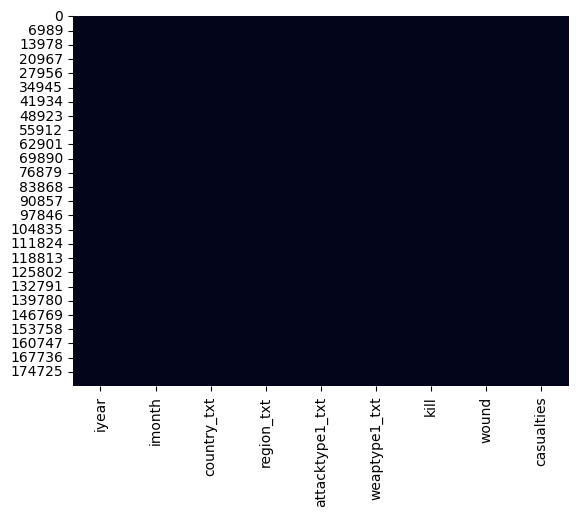

In [12]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

**What did you know about your dataset?**

The dataset contains global terrorism incidents from 1970 to 2017 with over 180,000 records. It includes features such as country, region, attack type, weapon type, and casualties. The dataset has missing values and shows skewed distributions, especially in casualties.

**Dataset Columns**

In [13]:
df.columns

Index(['iyear', 'imonth', 'country_txt', 'region_txt', 'attacktype1_txt',
       'weaptype1_txt', 'kill', 'wound', 'casualties'],
      dtype='object')

**Dataset Describe**

In [14]:
df.describe()

,iyear,imonth,kill,wound,casualties
count,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2002.638997,6.467277,2.266860,2.883296,5.150156
std,13.259430,3.388303,11.227057,34.309747,40.555416
min,1970.000000,0.000000,0.000000,0.000000,0.000000
25%,1991.000000,4.000000,0.000000,0.000000,0.000000
50%,2009.000000,6.000000,0.000000,0.000000,1.000000
75%,2014.000000,9.000000,2.000000,2.000000,4.000000
max,2017.000000,12.000000,1570.000000,8191.000000,9574.000000


**Check Unique Values**

In [15]:
for col in df.columns:
    print(col, df[col].nunique())

iyear 47
imonth 13
country_txt 205
region_txt 12
attacktype1_txt 9
weaptype1_txt 12
kill 205
wound 238
casualties 345


**Data Wrangling Code**

In [16]:
df.rename(columns={'nkill':'kill','nwound':'wound'}, inplace=True)

df = df[['iyear','imonth','country_txt','region_txt',
         'attacktype1_txt','weaptype1_txt','kill','wound']]

df = df.fillna(0)

df['casualties'] = df['kill'] + df['wound']

**What manipulations & insights?**

Columns were selected and renamed for clarity. Missing values were handled using fillna(). A new feature 'casualties' was created. The dataset shows strong skewness in casualties and concentration of attacks in specific regions.

# Chart 1 — Attacks per Year

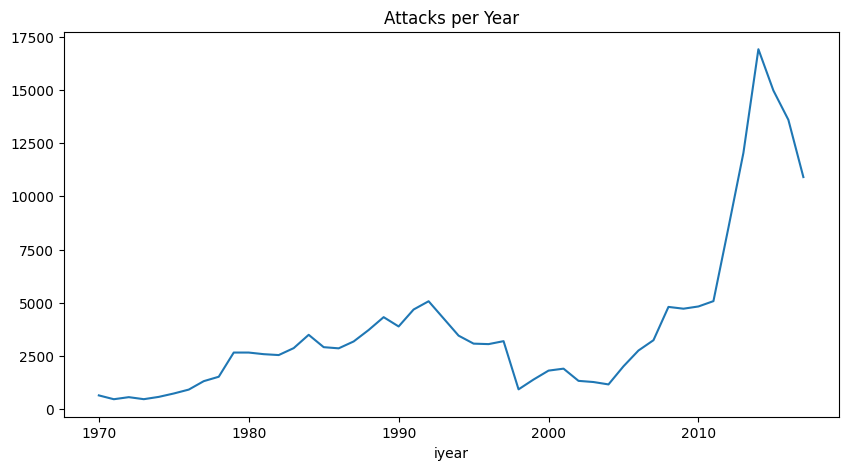

In [17]:
year_counts = df['iyear'].value_counts().sort_index()
year_counts.plot(figsize=(10,5))
plt.title("Attacks per Year")
plt.show()

# **Why?**

**Used line chart to analyze trends over time.**



# Insights-
**Attacks increased significantly after 2000.**


# Business Impact-

**Helps identify high-risk periods for better planning.**

## Chart 2 — Top Countries

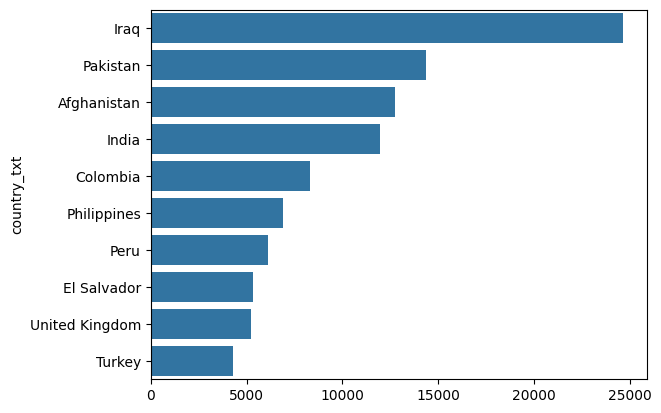

In [18]:
sns.barplot(x=df['country_txt'].value_counts().head(10).values,
            y=df['country_txt'].value_counts().head(10).index)
plt.show()

# Why: Compare countries
# Insight: Iraq & Afghanistan highest
# Impact: Resource allocation

# Chart 3 — Region Distribution

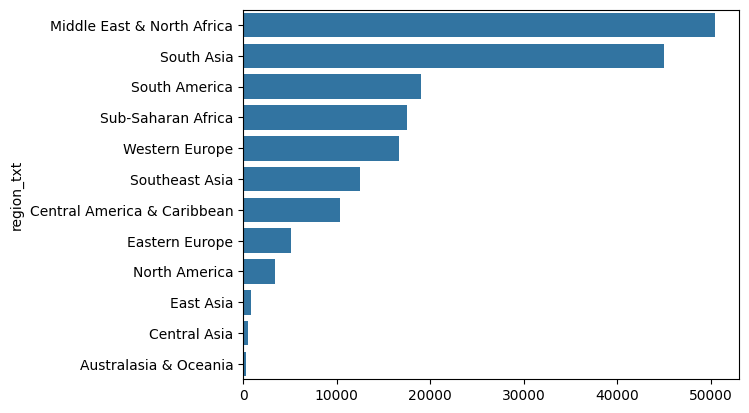

In [19]:
sns.barplot(x=df['region_txt'].value_counts().values,
            y=df['region_txt'].value_counts().index)
plt.show()

# Why:
Bar chart helps compare number of attacks across regions clearly.

# Insight:
Middle East & South Asia have the highest number of attacks.

# Impact:
Helps prioritize security efforts in high-risk regions.

# Chart 4 — Attack Types

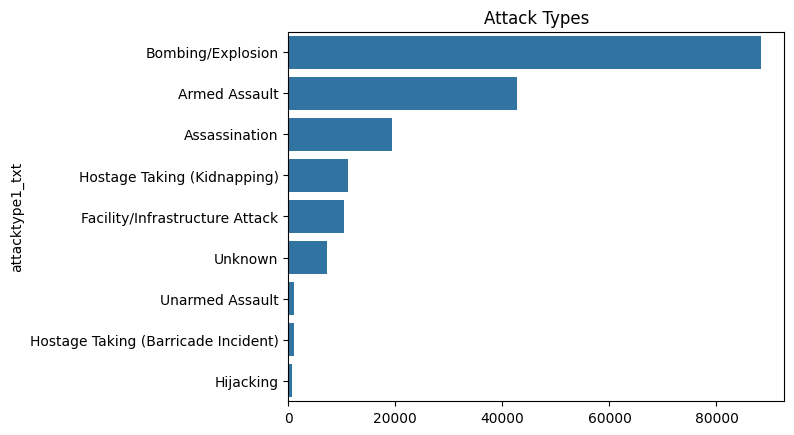

In [20]:
sns.barplot(x=df['attacktype1_txt'].value_counts().values,
            y=df['attacktype1_txt'].value_counts().index)
plt.title("Attack Types")
plt.show()

# Why: Compare frequency of different attack types.
# Insight: Bombing/Explosion is the most common attack type.
# Impact: Helps focus countermeasures on dominant attack methods.

# Chart 5 — Weapon Types

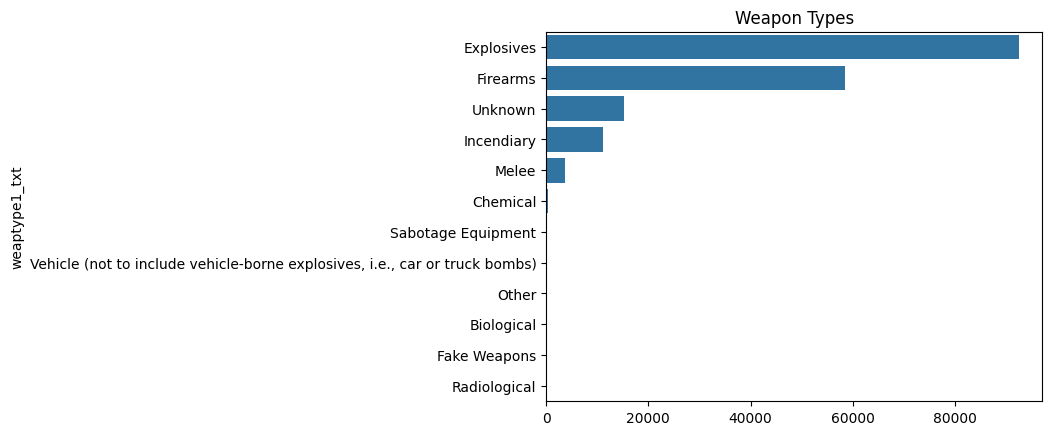

In [21]:
sns.barplot(x=df['weaptype1_txt'].value_counts().values,
            y=df['weaptype1_txt'].value_counts().index)
plt.title("Weapon Types")
plt.show()

# Why: Compare usage of different weapons.
# Insight: Explosives and firearms are most frequently used.
# Impact: Helps authorities control access to commonly used weapons.

# Chart 6 — Casualties Distribution (Log)

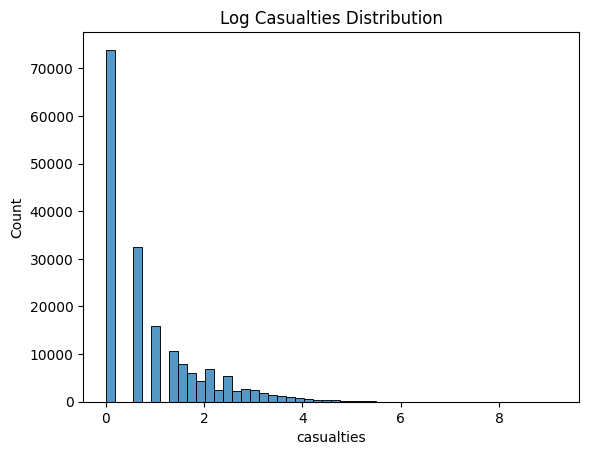

In [22]:
sns.histplot(np.log1p(df['casualties']), bins=50)
plt.title("Log Casualties Distribution")
plt.show()

# Why: Log scale helps visualize highly skewed data.
# Insight: Most attacks have low casualties with few extreme cases.
# Impact: Highlights need to prepare for rare but high-impact events.

# **Chart 7 — Top Deadly Countries**

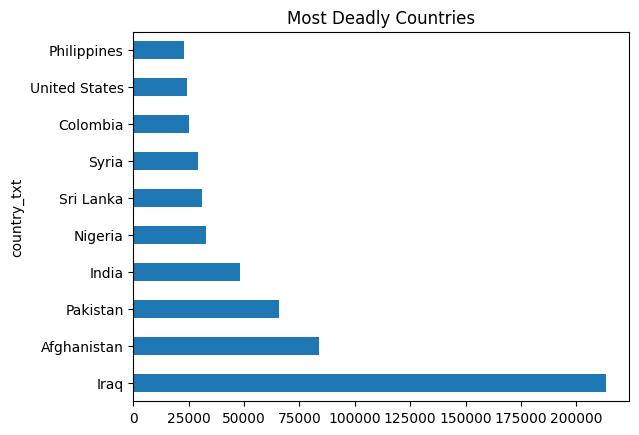

In [23]:
df.groupby('country_txt')['casualties'].sum().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title("Most Deadly Countries")
plt.show()

# Why: Shows countries with highest total casualties.
# Insight: Few countries contribute to majority of casualties.
# Impact: Helps prioritize international security interventions.

# Chart 8 — Attack Type vs Casualties

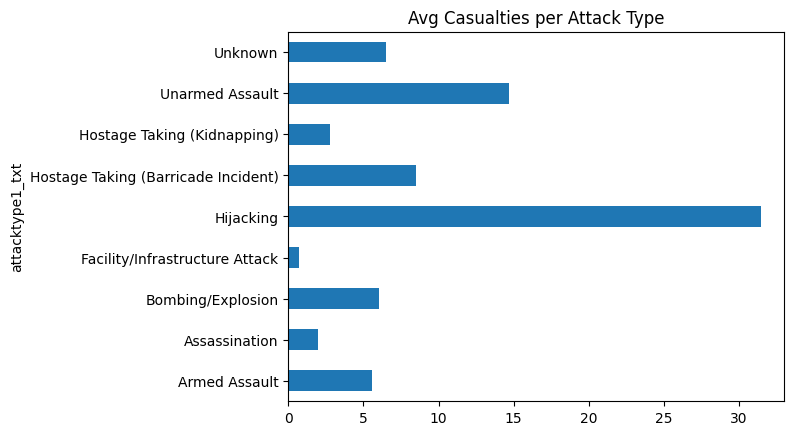

In [24]:
df.groupby('attacktype1_txt')['casualties'].mean().plot(kind='barh')
plt.title("Avg Casualties per Attack Type")
plt.show()

#Why: Compare severity across attack types.
#Insight: Some attack types cause more casualties on average.
#Impact: Helps identify high-impact attack methods.

# Chart 9 — Casualties Over Time

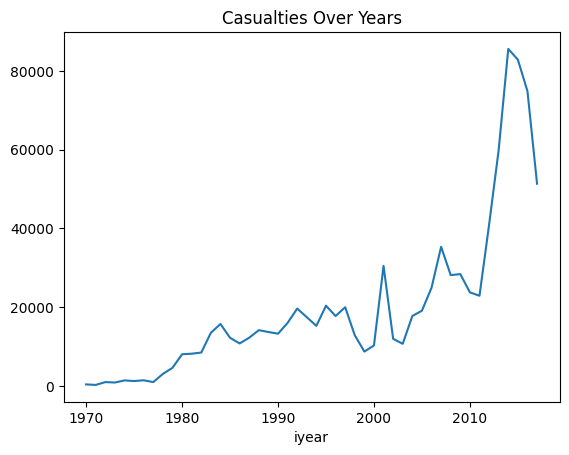

In [25]:
df.groupby('iyear')['casualties'].sum().plot()
plt.title("Casualties Over Years")
plt.show()

#Why: Analyze casualty trends over time.
#Insight: Casualties increased significantly in recent years.
#Impact: Indicates growing intensity of attacks.

# Chart 10 — Attacks by Month

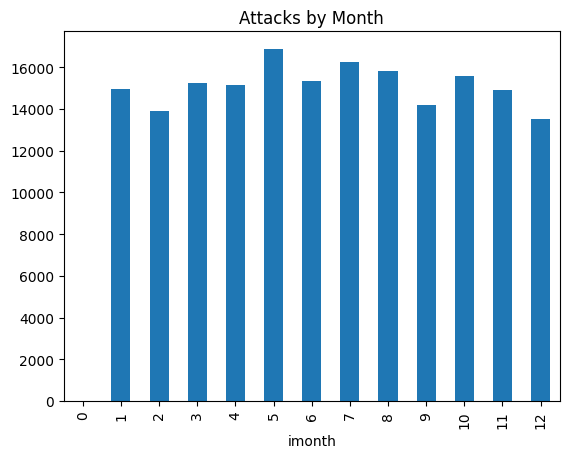

In [26]:
df['imonth'].value_counts().sort_index().plot(kind='bar')
plt.title("Attacks by Month")
plt.show()

#Why: Identify seasonal patterns in attacks.
#Insight: Attacks are relatively evenly distributed across months.
#Impact: Suggests year-round preparedness is required.

# Chart 11 — Boxplot of Casualties

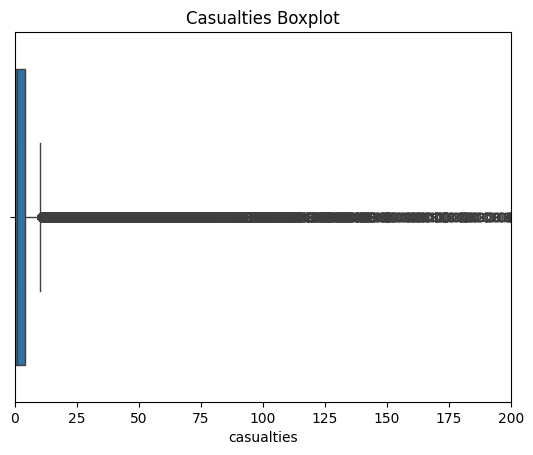

In [27]:
sns.boxplot(x=df['casualties'])
plt.xlim(0,200)
plt.title("Casualties Boxplot")
plt.show()

#Why: Detect outliers in casualties.
#Insight: Presence of extreme outliers in casualty data.
#Impact: Helps understand risk of rare but severe events

# Chart 12 — Region vs Casualties

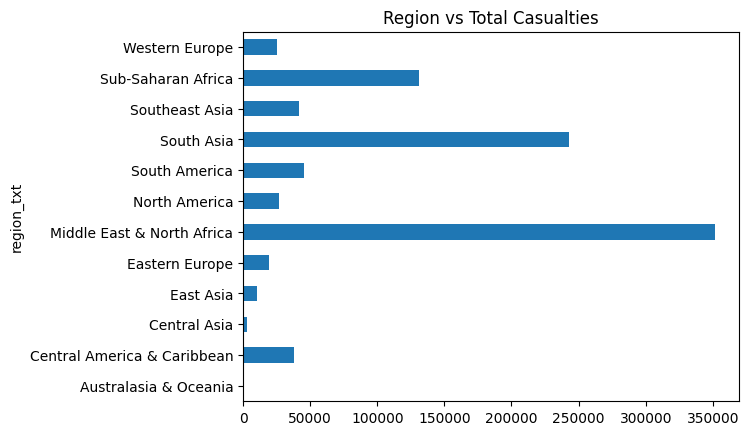

In [28]:
df.groupby('region_txt')['casualties'].sum().plot(kind='barh')
plt.title("Region vs Total Casualties")
plt.show()

#Why: Compare impact across regions.
#Insight: Some regions experience significantly higher casualties.
#Impact: Helps allocate emergency response resources effectively.

# Chart 13 — Kill vs Wound Scatter

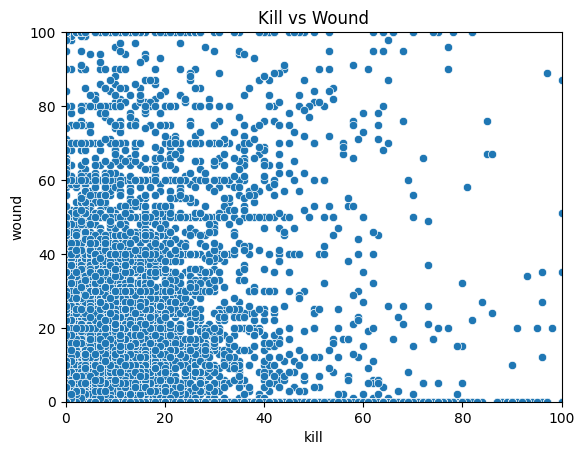

In [29]:
sns.scatterplot(x=df['kill'], y=df['wound'])
plt.xlim(0,100)
plt.ylim(0,100)
plt.title("Kill vs Wound")
plt.show()

#Why: Analyze relationship between kill and wound.
#Insight: Positive relationship between fatalities and injuries.
#Impact: Helps estimate severity of attacks.

# Chart 14 — Correlation Heatmap

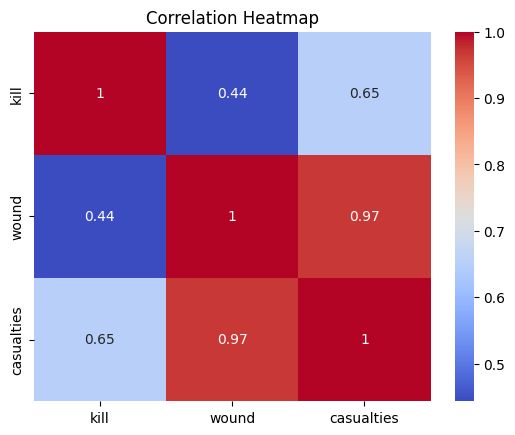

In [30]:
sns.heatmap(df[['kill','wound','casualties']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Why: Show correlation between numerical variables.
#Insight: Strong positive correlation between kill and casualties.
#Impact: Helps understand key drivers of attack severity

# Chart 15 — Pair Plot

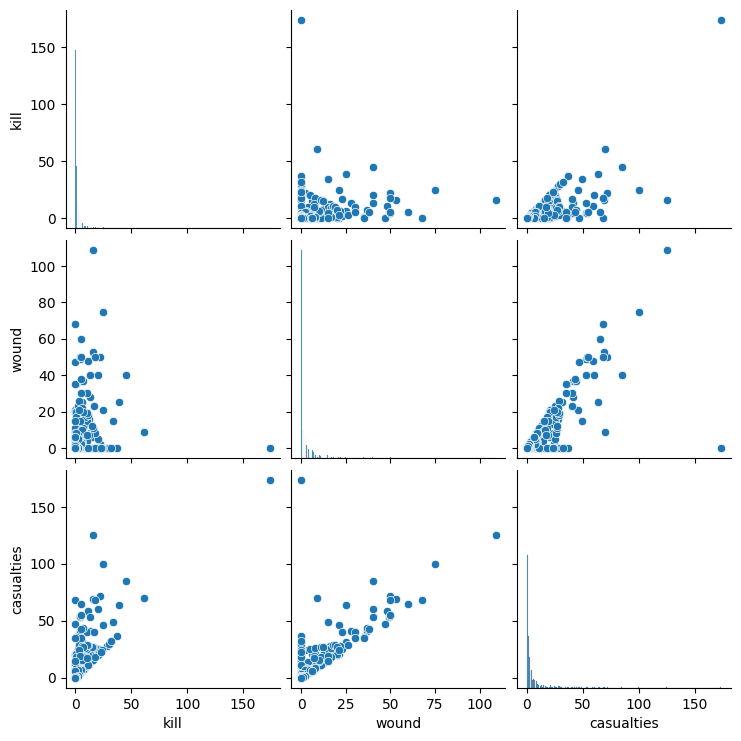

In [31]:
sns.pairplot(df[['kill','wound','casualties']].sample(1000))
plt.show()

#Why: Visualize multivariate relationships.
#Insight: Confirms distribution and correlation patterns.
#Impact: Provides deeper understanding of data behavior.

# SOME EXTRA GRAPHS FOR BETTER VISUALIZATION AS WE AE USING DIFFRENT GRAPHS TO HANDLE OUTLIERS AND USING LOG FUNCION AND KDE

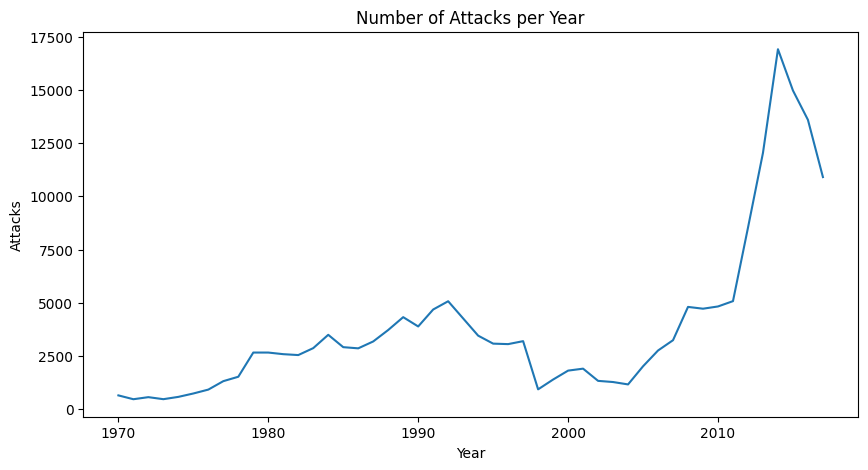

In [32]:
year_counts = df['iyear'].value_counts().sort_index()

plt.figure(figsize=(10,5))
year_counts.plot(kind='line')
plt.title("Number of Attacks per Year")
plt.xlabel("Year")
plt.ylabel("Attacks")
plt.show()

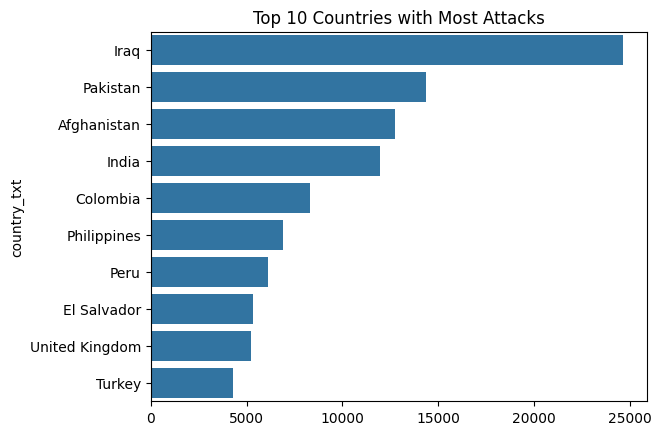

In [33]:
top_countries = df['country_txt'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries with Most Attacks")
plt.show()

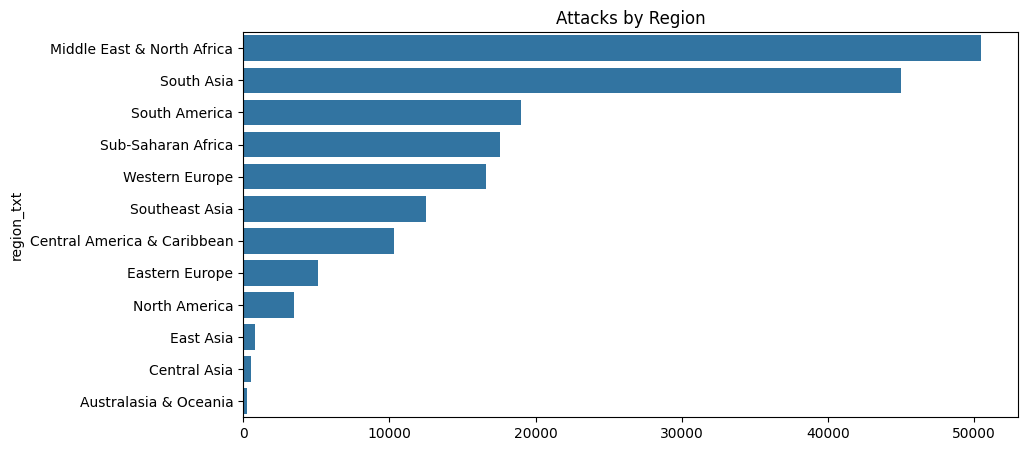

In [34]:
region_counts = df['region_txt'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=region_counts.values, y=region_counts.index)
plt.title("Attacks by Region")
plt.show()

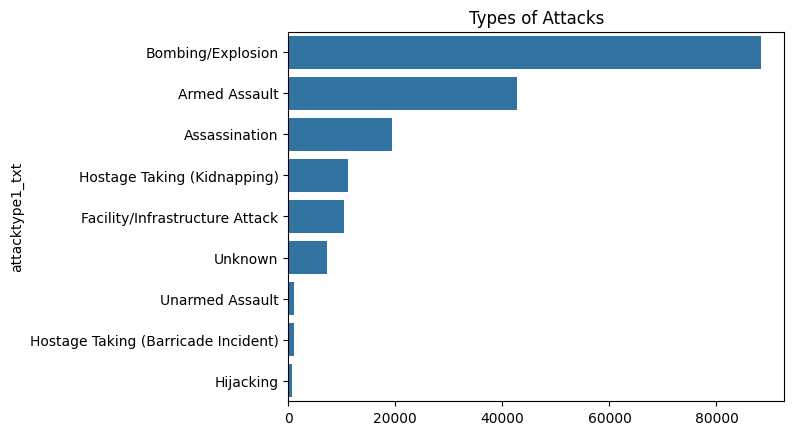

In [35]:
attack_types = df['attacktype1_txt'].value_counts()

sns.barplot(x=attack_types.values, y=attack_types.index)
plt.title("Types of Attacks")
plt.show()

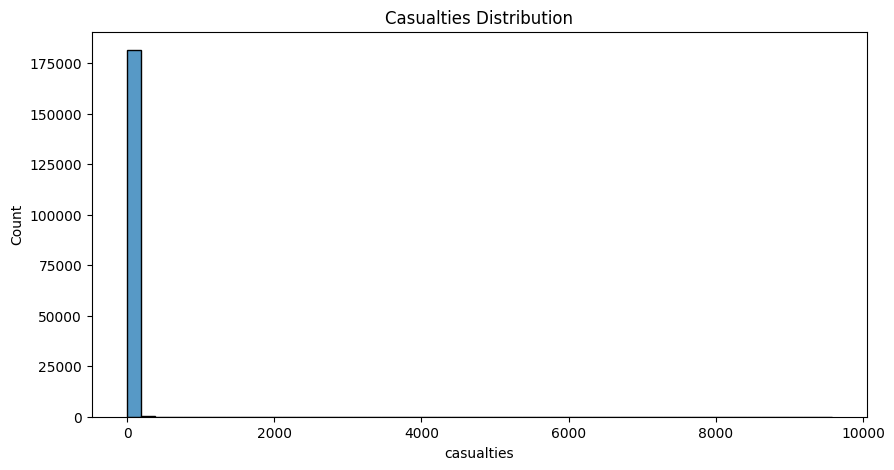

In [38]:
df['casualties'] = df['kill'] + df['wound']

plt.figure(figsize=(10,5))
sns.histplot(df['casualties'], bins=50)
plt.title("Casualties Distribution")
plt.show()

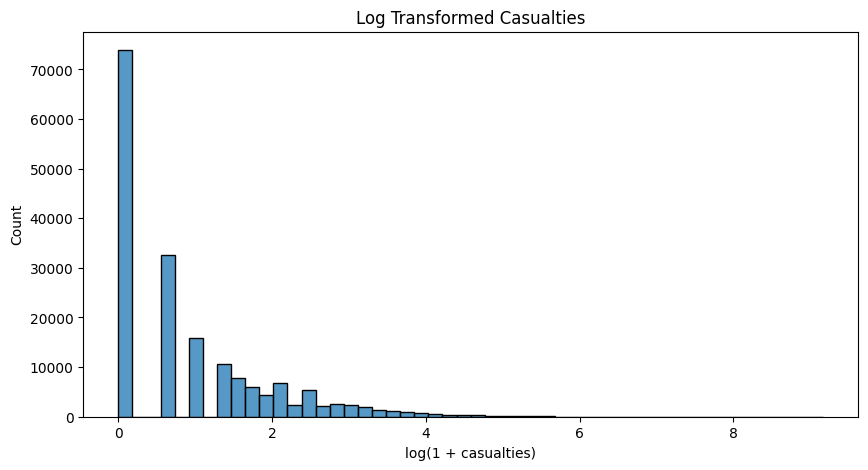

In [39]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df['casualties']), bins=50)
plt.title("Log Transformed Casualties")
plt.xlabel("log(1 + casualties)")
plt.show()

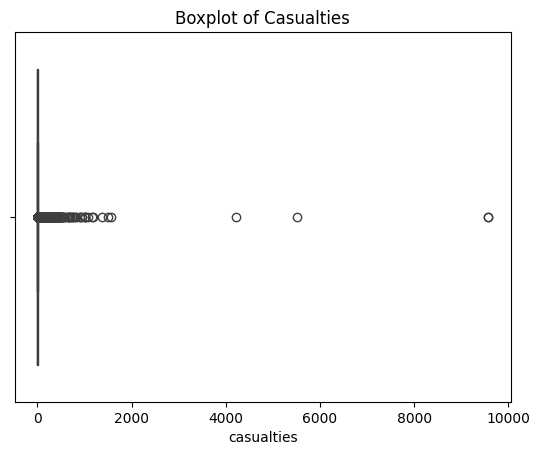

In [40]:
sns.boxplot(x=df['casualties'])
plt.title("Boxplot of Casualties")
plt.show()

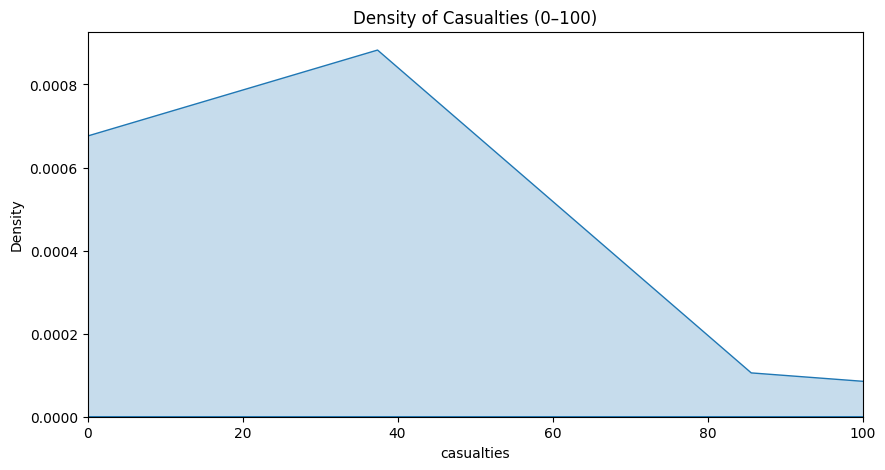

In [41]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['casualties'], fill=True)
plt.xlim(0,100)
plt.title("Density of Casualties (0–100)")
plt.show()

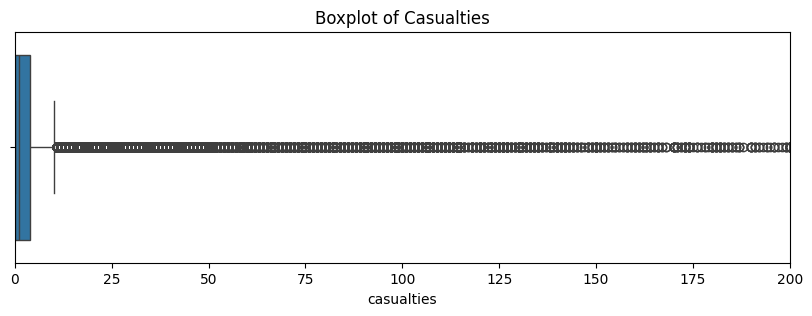

In [42]:
plt.figure(figsize=(10,3))
sns.boxplot(x=df['casualties'])
plt.xlim(0,200)
plt.title("Boxplot of Casualties")
plt.show()

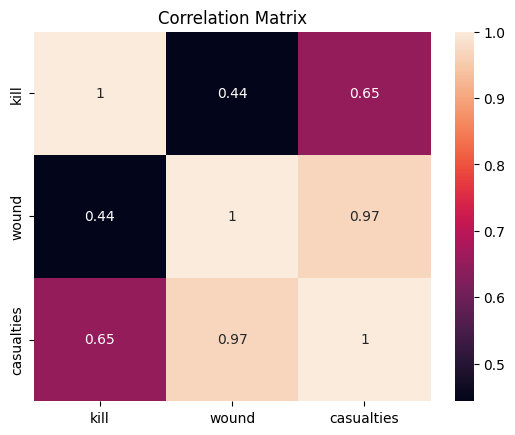

In [44]:
sns.heatmap(df[['kill','wound','casualties']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

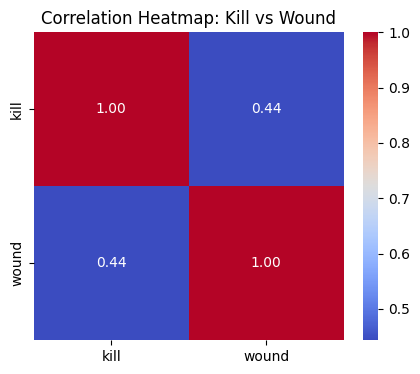

In [45]:
df.rename(columns={
    'kill': 'kill',
    'wound': 'wound'
}, inplace=True)
corr = df[['kill', 'wound']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Kill vs Wound")
plt.show()

# **Solution to Business Objective**

Based on the analysis, it is recommended that governments and security agencies focus their efforts on high-risk regions such as the Middle East and South Asia, where the majority of terrorist activities are concentrated. Special attention should be given to the most common attack types, particularly bombings and explosions, by strengthening surveillance, intelligence gathering, and preventive measures.

Additionally, since a small number of attacks result in extremely high casualties, emergency response systems and disaster preparedness should be improved to handle such high-impact incidents effectively. Monitoring trends over time can also help in predicting potential surges in terrorist activities and taking proactive actions.

Overall, data-driven decision-making should be adopted to allocate resources efficiently, enhance security strategies, and minimize the impact of future terrorist attacks.

# **Conclusion**
In this project, we performed exploratory data analysis on the Global Terrorism Dataset to understand patterns, trends, and relationships in terrorist activities from 1970 to 2017. Through various visualizations, we identified key insights such as the increase in attacks over time, the most affected regions and countries, and the most common attack and weapon types.

The analysis also revealed that while most attacks result in low casualties, a few incidents cause extremely high damage, indicating a highly skewed distribution. Correlation analysis showed a positive relationship between the number of people killed and wounded, highlighting the severity of certain attacks.

Overall, this project demonstrates how data analysis can be used to gain meaningful insights into global issues. The findings can assist policymakers and security agencies in making informed decisions, improving preparedness, and reducing the impact of terrorism.